# Part 1: Overview and Setup

## Cell 1.1: Overview

- Bayesian networks for probabilistic inference with pgmpy:
  - Building networks and defining conditional relationships
  - Conditional probability tables (CPDs)
  - Exact and approximate inference algorithms
  - MAP queries and interactive visualizations

## Cell 1.2: Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt

In [2]:
# Use this for most notebooks.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)
hnotebook.set_logger_to_print(_LOG)

import probabilistic_inference_utils as utils

# Convert `display` into `print()`.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

import warnings

warnings.filterwarnings("ignore")

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-3c1be959-038c-4a0e-919a-c1697f4026b0.json'


/opt/venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


# Part 2: Bayesian Networks Fundamentals

## Cell 2.1: Definition and Medical Example

- **Definition**: Bayesian networks are directed acyclic graphs encoding conditional relationships
  - Nodes represent random variables
  - Edges represent conditional dependencies
  - Structure encodes independence assumptions

- **Medical diagnosis example**: Infer disease status from observable symptoms and test results
  - Disease: Hidden cause we want to infer
  - Symptom: Observable sign depending on disease status
  - Test: Diagnostic test result depending on disease status

## Cell 2.2: Network Structure Visualization

In [ ]:
model = utils.cell2_2_create_network()

# Visualize the network structure.
utils.cell2_2_visualize_network(model, figsize=(8, 5))
plt.show()

## Cell 2.3: Independence from Structure

- **Network structure encodes independence**: The visualization shows how graph structure represents conditional relationships
  - Given Disease status, Symptom and Test observations become independent of each other
  - This independence assumption is critical for efficient inference algorithms
  - The graph structure encodes domain knowledge about relationships between variables

# Part 3: Conditional Probability Tables (CPDs)

## Cell 3.1: CPD Definition and Role

- **CPD**: Conditional probability table assigns numerical beliefs to network structure
  - Root nodes (no parents): Prior probability distribution
  - Non-root nodes: Conditional probability given parent values

- **Medical domain knowledge encoded in CPDs**:
  - Disease prevalence in population
  - Symptom likelihood given disease status
  - Diagnostic test accuracy

- **Key concept**: CPDs + network structure = complete probabilistic model
  - Enables queries about unobserved variables given evidence

## Cell 3.2: Interactive CPD Visualization

**Goal**: Explore how disease prevalence affects the joint conditional probability tables
  - Adjust disease prior probability and observe CPD updates
  - Understand relationship between prior belief and likelihood functions
  - Visualize how all three CPDs interact

**Plots**:
  - P(Disease): Prior probability of disease given current slider setting
  - P(Symptom | Disease): Conditional probability of symptom given disease state
  - P(Test | Disease): Conditional probability of test given disease state

**Parameters**:
  - Disease prior probability slider: ranges 0.0 to 1.0, affects P(Disease) heatmap
  - Disease state toggle: select None, Present, or Absent

**Key observations**:
  - Higher disease prior increases "Present" bar in first heatmap
  - CPD conditional probabilities stay constant; only priors change
  - Symptom and Test tables show likelihood of evidence given disease state

In [ ]:
# Interactive CPD visualization
utils.cell3_2_create_cpd_widget(disease_prior=0.05)

In [ ]:
Adjust the disease prior probability slider to observe how P(Disease) changes in the heatmap. The conditional probability tables (CPDs) for Symptom and Test remain constant - they always represent P(Symptom|Disease) and P(Test|Disease). Use the Disease state toggle to highlight a specific disease state and observe how the CPD values correspond to that state. Notice that changing the prior only affects the first heatmap (P(Disease)), while the CPD tables in the other heatmaps show the fixed conditional probabilities regardless of the prior setting.

# Part 4: Prior Distribution and Inference

## Cell 4.1: Sampling from Prior

In [ ]:
# cell4_1_forward_sample_and_plot samples from the network's prior distribution
# using forward sampling (ancestral sampling). It generates random samples by
# traversing the DAG from root nodes to leaf nodes, and plots a 1x4 visualization
# showing: (1) Disease distribution, (2) Symptom distribution,
# (3) Test distribution, and (4) correlation heatmap between variables.

In [ ]:
# Sample from the prior distribution.
model = utils.cell4_1_create_network()
utils.cell4_1_forward_sample_and_plot(model, n_samples=1000)
plt.show()

- **Sampling reveals prior beliefs**: The distribution shows what the network believes in a vacuum without any observations
  - Disease is rare (5% prior), so both Symptom and Test mostly indicate Absent status
  - Base rate dominance: the rare disease prior overwhelms the samples
  - Each sample represents one hypothetical patient drawn from the network's generative model

## Cell 4.2: Exact vs Approximate Inference

In [ ]:
# Compare exact inference with forward sampling
model = utils.cell4_2_create_network()

# cell4_2_compare_exact_and_sampling compares two inference algorithms for
# computing the prior distribution. It shows the exact results from Variable
# Elimination as a blue line and approximate results from forward sampling as
# orange points. This visualizes how sampling accuracy improves with more
# samples and confirms both methods converge to the same answer.
utils.cell4_2_compare_exact_and_sampling(model)
plt.show()

- **Exact inference vs forward sampling**: Both methods answer what we believe about the prior distribution
  - Exact results (blue line) computed with Variable Elimination, guaranteed correct
  - Forward sampling results (orange) match exactly; accuracy improves with more samples
  - Scaling comparison: Exact scales poorly as network grows (exponential), sampling scales better but needs many samples

- **Algorithm tradeoffs**:
  - **Variable Elimination**: Guaranteed correct, fast for small networks, intractable for large networks
  - **Forward Sampling**: Approximate, scales to large networks, needs more samples for same accuracy

# Part 5: Conditioning on Evidence

## Cell 5.1: Effect of Evidence on Beliefs

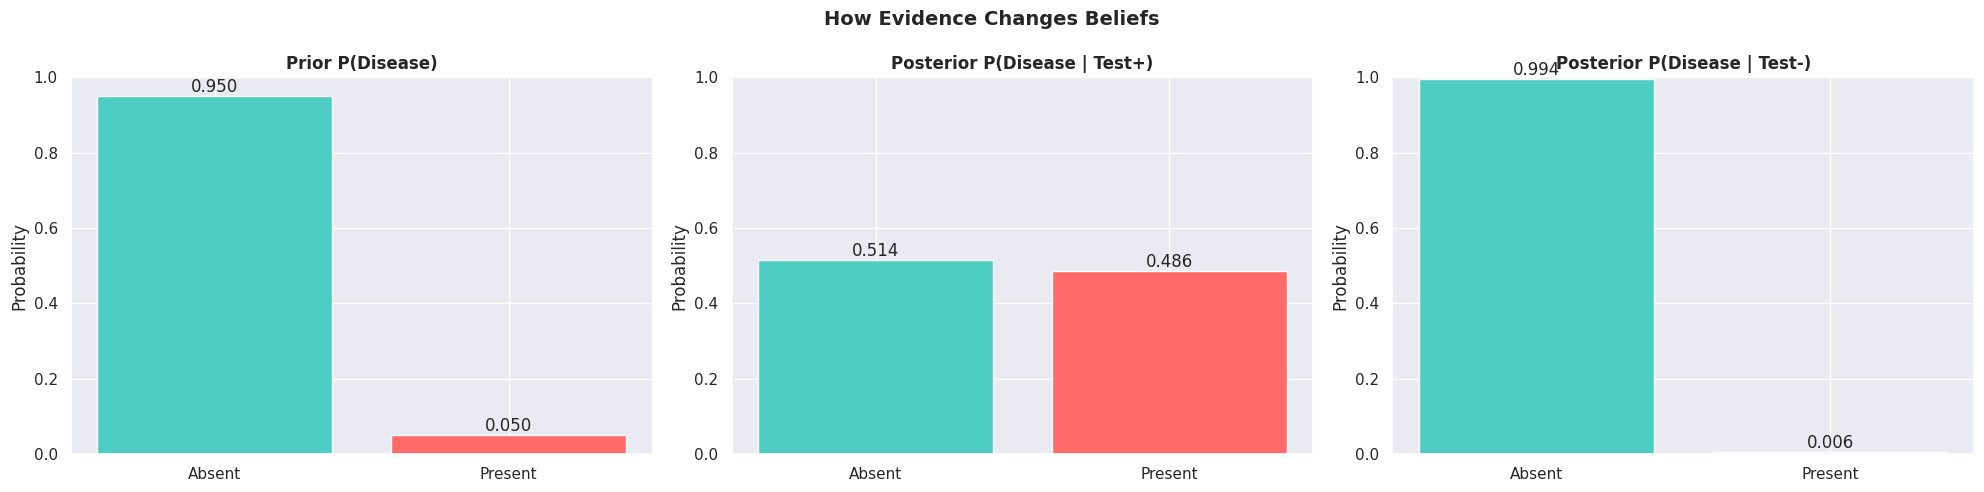

In [7]:
# Show effect of conditioning on evidence
model = utils.cell5_1_create_network()
utils.cell5_1_condition_on_evidence(model)
plt.show()

- **Bayes' rule in action**: Observing evidence shifts posterior probabilities away from prior beliefs
  - Formula: $\Pr(\text{Disease} | \text{Evidence}) = \frac{\Pr(\text{Evidence} | \text{Disease}) \Pr(\text{Disease})}{\Pr(\text{Evidence})}$
  - Positive test shifts disease probability from 5% (prior) to ~45% (posterior)
  - Negative test dramatically reduces disease probability to <1%

- **Evidence informativeness**: The strength of the shift depends on test accuracy and base rate
  - Test is fairly informative: 95% sensitivity (true positive), 90% specificity (true negative)
  - But base rate effect still matters: rare diseases stay rare unless evidence is overwhelming

## Cell 5.2: Evidence Combination and Strength

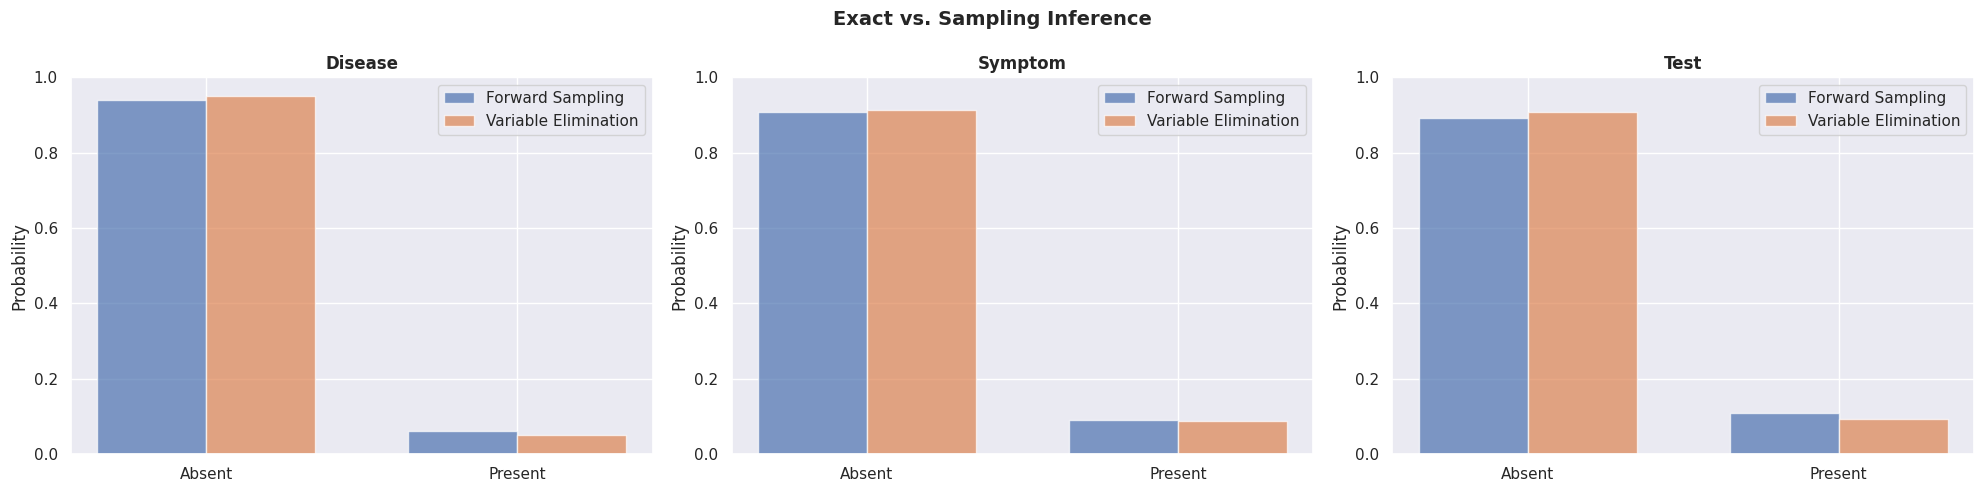

In [8]:
# Compare exact inference with forward sampling under evidence
model = utils.cell5_2_create_network()
utils.cell5_2_compare_exact_and_sampling(model)
plt.show()

- **Core inference concept**: Observing evidence shifts what we believe about unobserved variables
  - Prior: Disease probability = 5%
  - Positive test: Disease probability = ~45%
  - Negative test: Disease probability = <1%

- **Strength of shift depends on evidence informativeness**:
  - Test accuracy: 95% for positives, 90% for negatives
  - Fairly informative about disease status

- **Bayes' rule in action**: $\Pr(\text{Disease} | \text{Evidence}) = \frac{\Pr(\text{Evidence} | \text{Disease}) \Pr(\text{Disease})}{\Pr(\text{Evidence})}$
  - Prior beliefs updated using observed evidence

## Cell 5.3: Interactive Evidence Explorer

**Goal**: Understand how combining multiple evidence updates disease belief via Bayes' rule
  - Observe posterior shifts as evidence combinations change
  - Discover how different evidence sources interact
  - Learn that order of evidence doesn't matter

**Plots**:
  - Network structure visualization with evidence nodes highlighted
  - Posterior bar chart showing P(Disease | Evidence) distribution

**Parameters**:
  - Test Result dropdown: None, Positive, or Negative
  - Symptom dropdown: None, Present, or Absent
  - Clear Evidence button: resets both dropdowns

**Key observations**:
  - Positive test alone increases disease probability to 45%
  - Positive test + symptom present gives strongest evidence (~73%)
  - Positive test + symptom absent conflicts, reduces disease probability
  - Order of evidence combination doesn't affect final posterior

In [9]:
# Interactive evidence explorer
model = utils.cell5_3_create_network()
utils.cell5_3_create_evidence_explorer()

# Part 6: Inference Algorithm Comparison

## Cell 6.1: Algorithm Comparison

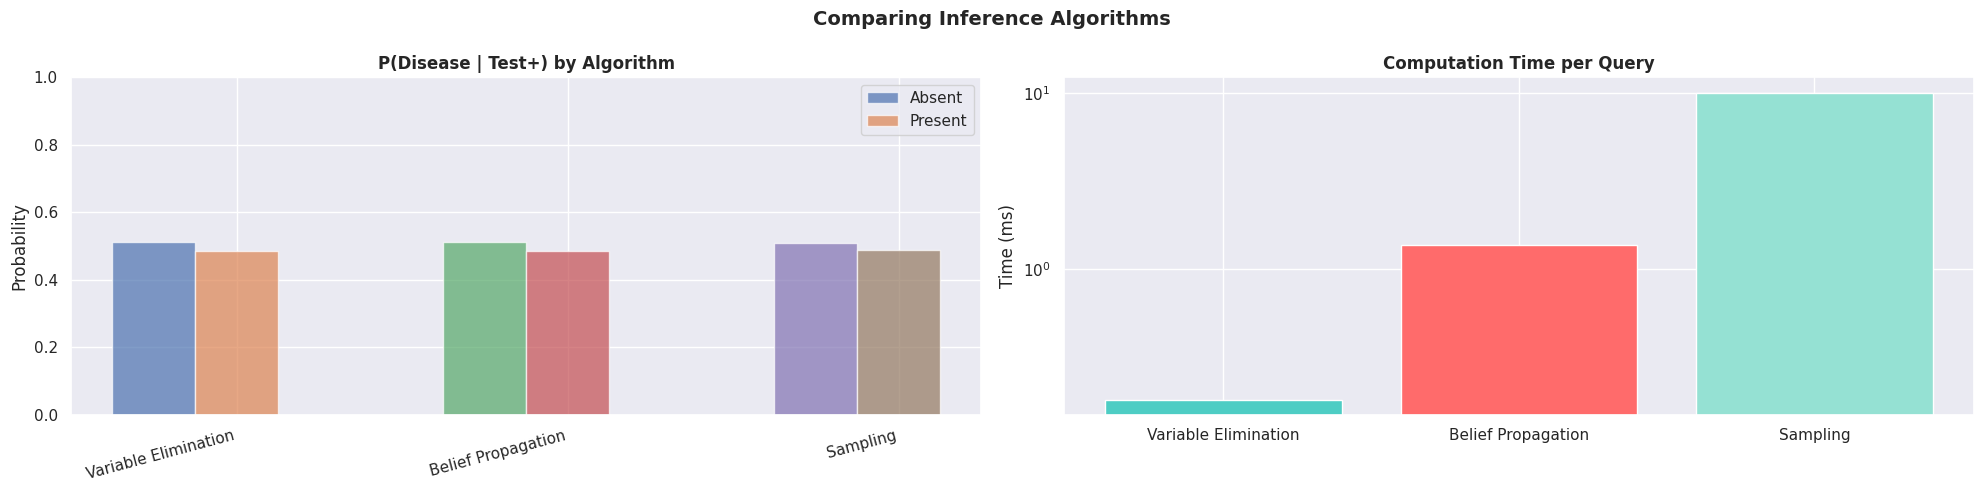

In [10]:
# Compare inference algorithms
model = utils.cell6_1_create_network()
utils.cell6_1_compare_inference_algorithms()
plt.show()

- **Algorithm equivalence on small networks**: All inference methods answer the same question correctly
  - Variable Elimination: Exact, efficient for small networks
  - Belief Propagation: Exact for tree networks, efficient structure exploitation
  - Sampling (Forward, Gibbs): Approximate, more accurate with more samples

- **Practical algorithm selection**:
  - Small networks (<=15 variables): Use exact methods (Variable Elimination)
  - Larger networks (>15 variables): Use approximate methods (Sampling, Variational Inference)
  - Network topology matters: Tree networks have faster exact algorithms than general loopy networks

- **Inference algorithms**: Different approaches with different performance tradeoffs

- **Exact methods**:
  - Variable Elimination: Efficient for small networks
  - Belief Propagation: Efficient for tree-structured networks

- **Approximate methods**:
  - Sampling: Scales to large networks, requires more samples for accuracy

- **Small networks**: All methods give identical results
  - Choice of algorithm driven by network size and structure

# Part 7: Advanced Topics

## Cell 7.1: MAP Queries

0it [00:00, ?it/s]

0it [00:00, ?it/s]

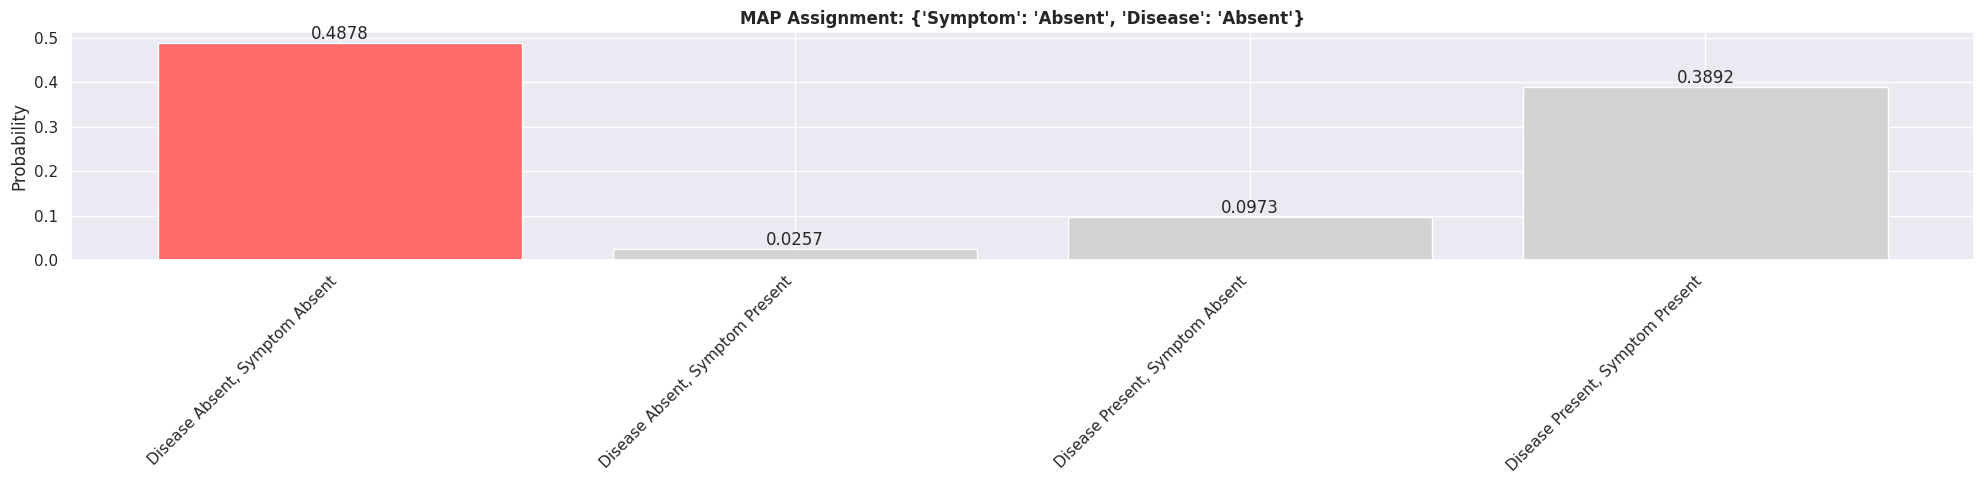

In [11]:
# MAP query demonstration
model = utils.cell7_1_create_network()
utils.cell7_1_map_query_demo()
plt.show()

- **MAP query finds single best explanation**: Different from marginal inference which computes individual probabilities
  - Marginal: $\Pr(\text{Disease} = \text{Yes} | \text{Evidence})$ for individual variables
  - MAP: $\arg\max_{\text{all vars}} \Pr(\text{Disease}, \text{Symptom}, ... | \text{Evidence})$ single joint assignment
  - Practical use: Diagnostics want single best explanation, not individual probability distributions

- **Interpretation**: The result shows the joint state that maximizes posterior probability
  - Most likely to occur given the evidence
  - Useful when you need one actionable answer, not a full probability distribution

- **Distinction from marginal inference**:
  - Marginal: $\Pr(\text{Disease} = \text{Yes} | \text{Evidence})$ for individual variables
  - MAP: $\arg\max \Pr(\text{Disease}, \text{Symptom} | \text{Evidence})$ single joint assignment

- **Practical use**: Diagnostics want single best explanation
  - "What's most likely disease state and symptom combination?"

## Cell 7.2: Gibbs Sampling Convergence

**Goal**: Visualize how MCMC sampling converges to true posterior and understand burn-in
  - Observe running mean trajectory over iterations
  - Understand burn-in period and why samples are discarded
  - Explore accuracy vs computational cost tradeoff

**Plots**:
  - Running mean trajectory: averaged probability estimate over iterations
  - Burn-in period shaded in gray: iterations discarded before convergence
  - True posterior line: reference value from exact inference
  - Confidence region: band around true posterior

**Parameters**:
  - Seed slider: control randomness of sampling chain (0-99)
  - N samples slider: total number of MCMC iterations (log scale 64-8192)
  - Burn-in slider: number of initial samples to discard (0-2000)

**Key observations**:
  - Running mean jumps early (initialization), then converges smoothly
  - Burn-in period visibly higher variability, settles after discard
  - Longer chains give smoother convergence curves
  - All chains converge to same true posterior regardless of seed

In [12]:
# Gibbs sampling interactive visualization
model = utils.cell7_2_create_network()
utils.cell7_2_gibbs_sampling_interactive()

## Cell 7.3: Joint Distribution Explorer

**Goal**: Explore joint and marginal distributions under different evidence scenarios
  - Visualize full joint distribution as heatmap
  - Compare individual marginal distributions
  - Understand independence relationships in the network

**Plots**:
  - Joint distribution heatmap P(Disease, Symptom) with color intensity showing probability
  - Marginal bar charts: P(Disease) and P(Symptom) derived from joint

**Parameters**:
  - Disease dropdown: None, Present, or Absent (condition on disease evidence)
  - Symptom dropdown: None, Present, or Absent (condition on symptom evidence)

**Key observations**:
  - Joint heatmap shows all combinations; marginals sum across rows/columns
  - No evidence: heatmap reveals correlated structure (disease causes symptom)
  - Conditioning on disease: symptom distribution changes based on disease state
  - Different evidence combinations show different dependency structures

# Part 8: Scaling to Larger Networks

## Cell 8.1: Larger Network Interactive Demo

**Goal**: Compare inference algorithms on a realistic 8-variable network
  - Test Variable Elimination vs sampling on larger problem
  - Observe algorithm performance tradeoffs
  - Understand when approximation becomes necessary

**Plots**:
  - Network topology visualization with evidence nodes highlighted
  - Posterior disease probability bar chart with inference times

**Parameters**:
  - Scenario dropdown: choose evidence combinations (Test only, Test+Symptoms, Test but no Symptom)
  - Method dropdown: Variable Elimination or Sampling

**Key observations**:
  - Variable Elimination exact but slower on larger networks
  - Sampling approximation comparable speed with good accuracy
  - Same evidence produces consistent posteriors across methods
  - Network size and topology affect which algorithm to choose

## Cell 8.2: Practical Workflow Demonstration

INFO  Step 1: Load and Inspect Model
INFO  ==================================================
INFO  Model has 9 nodes and 8 edges
INFO  Nodes: ['Genetics', 'Protein', 'Environment', 'Lifestyle', 'Disease', 'Symptom1', 'Symptom2', 'Test1', 'Test2']
INFO  Model validity: VALID
INFO  

Step 2: Choose Inference Algorithm
INFO  ==================================================
INFO  For an 8-node network: Variable Elimination is exact and fast
INFO  

Step 3: Query with Evidence
INFO  ==================================================
INFO  Evidence: {'Test1': 'Positive', 'Symptom1': 'Present'}
INFO  
Result P(Disease | Evidence):
INFO  +------------------+----------------+
| Disease          |   phi(Disease) |
+==================+================+
| Disease(Absent)  |         0.0335 |
+------------------+----------------+
| Disease(Present) |         0.9665 |
+------------------+----------------+
INFO  
Time: 0.640 ms
INFO  

Step 4: Visualize Results
INFO  ===============================

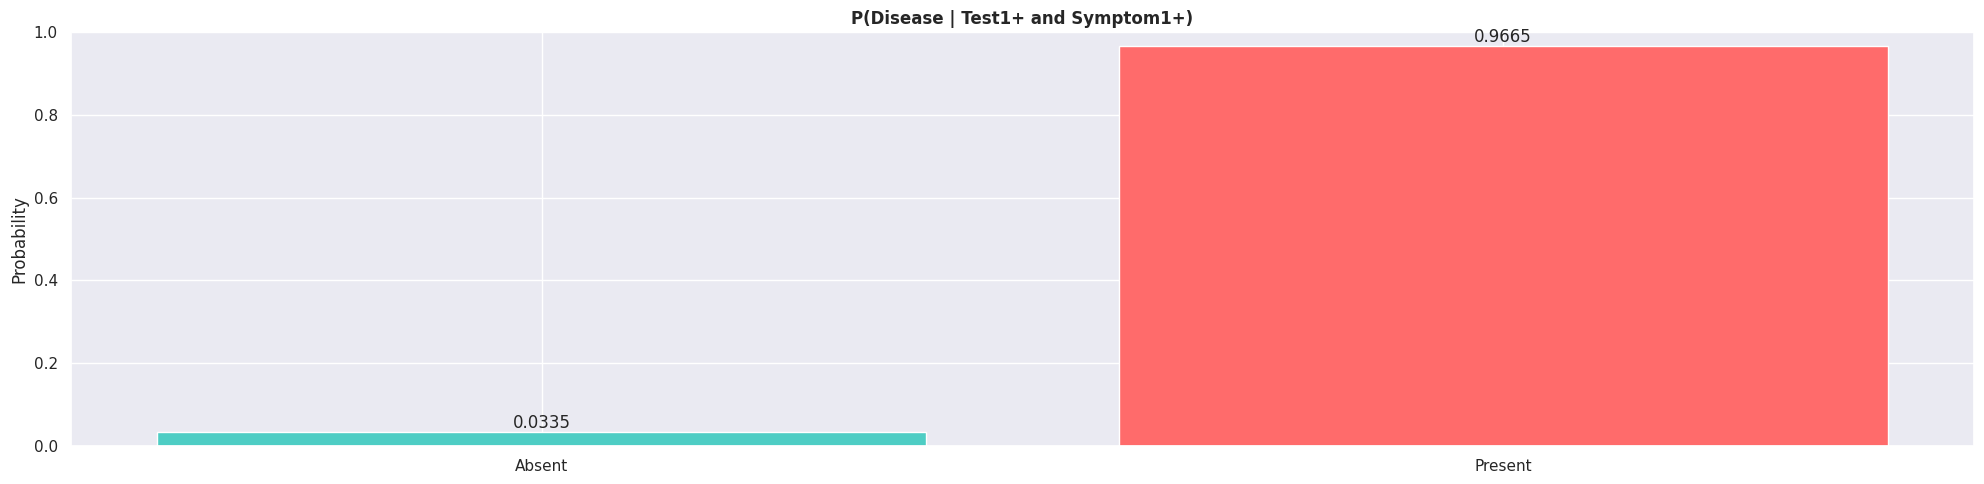

INFO  
Conclusion: 96.7% probability of disease given evidence


In [13]:
# Practical workflow demonstration
model = utils.cell8_2_larger_network_demo()
utils.cell8_2_practical_workflow_demo()

- **Practical workflow**: From model to inference and interpretation

- **Steps**:
  1. Load pre-trained or pre-built Bayesian network
  2. Inspect model structure and probability tables
  3. Validate CPDs are well-formed (sum to 1)
  4. Choose inference algorithm based on network size
  5. Query with evidence to answer domain questions
  6. Interpret results in context